In [4]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data=pd.read_csv(r"D:\data preprocessing\Labtop_data\Laptop_price.csv")

##
EdA

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   str    
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Storage_Capacity  1000 non-null   int64  
 4   Screen_Size       1000 non-null   float64
 5   Weight            1000 non-null   float64
 6   Price             1000 non-null   float64
dtypes: float64(4), int64(2), str(1)
memory usage: 58.7 KB


In [7]:
data.describe(include=["int","float"])

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.750611,15.500000,584.576000,14.056790,3.466919,19604.187963
std,0.731796,10.988665,313.438517,1.705882,0.866541,9406.064880
min,1.511580,4.000000,256.000000,11.012111,2.000560,8570.012950
25%,2.089246,8.000000,256.000000,12.635523,2.717211,10114.012948
50%,2.760885,16.000000,512.000000,14.099643,3.464630,17287.241878
75%,3.362610,32.000000,1000.000000,15.528590,4.212583,31566.214754
max,3.998534,32.000000,1000.000000,16.985737,4.990728,33503.935037


In [8]:
data.head(10)

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718
5,HP,1.881348,16,256,11.943958,4.840268,9543.719980
6,Lenovo,2.940721,32,256,11.713246,4.344846,10390.137319
7,Lenovo,3.016788,4,256,15.588315,2.941120,9214.484506
8,Lenovo,2.560327,4,512,15.026332,2.743620,16372.175284
9,Acer,3.341111,32,512,13.611945,4.093149,18501.832733


In [9]:
def valuess(dataa):
    liststring=dataa.select_dtypes(include=["str","float"]).columns
    for i in liststring:
        value=dataa[i].nunique()
        print(f"the values for column --{i}-- is-->",value)
        print(dataa[i].unique())

valuess(data)

the values for column --Brand-- is--> 5
<ArrowStringArray>
['Asus', 'Acer', 'Lenovo', 'HP', 'Dell']
Length: 5, dtype: str
the values for column --Processor_Speed-- is--> 1000
[3.83029571 2.91283296 3.24162706 3.80624845 3.26809659 1.88134761
 2.9407209  3.01678762 2.56032668 3.34111059 3.83591754 3.81392128
 2.62709843 1.78309511 3.962103   3.59724522 1.8116567  3.80210471
 3.67474091 2.79709514 2.97818859 2.49750676 1.6369041  2.3379931
 3.50713362 1.51158006 2.33374793 2.49542173 2.84348901 3.79963904
 2.36586499 2.367383   3.34375312 2.63054485 2.06151206 2.63109879
 1.85214255 1.94096747 2.74591943 2.54731362 3.78711475 2.40598475
 2.95147088 3.08066072 1.53273614 3.15884343 1.94508992 3.90267579
 1.87165682 2.53656031 1.71337417 3.99218563 2.75548753 2.98846254
 1.66769119 3.37490118 2.02476398 3.74513572 2.0128491  1.9767193
 1.59137417 2.68016736 2.91210283 1.6642716  3.43881904 2.63322209
 2.81097567 2.60190687 2.50190765 2.89910083 1.88810061 1.95482033
 3.65446405 3.86528866 

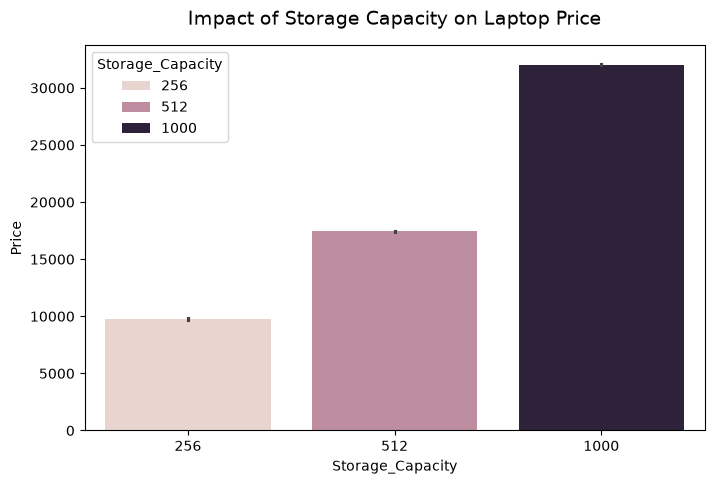

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=data,
    x="Storage_Capacity",
    y="Price",
    hue="Storage_Capacity",
)
plt.title("Impact of Storage Capacity on Laptop Price", fontsize=14, pad=15)
plt.show()

<Axes: xlabel='Screen_Size', ylabel='Weight'>

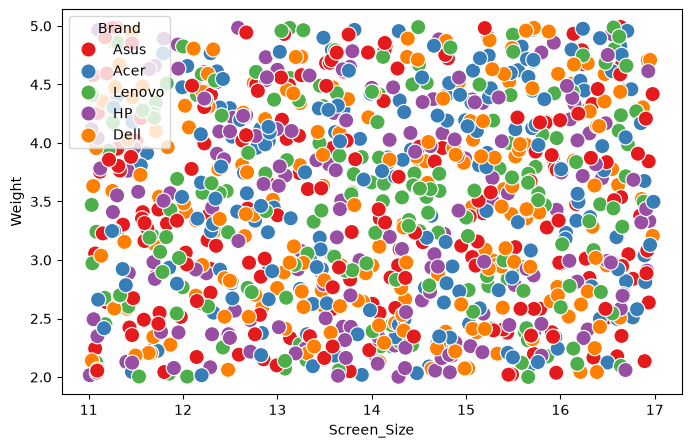

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=data, x="Screen_Size", y="Weight", hue="Brand", s=120, palette="Set1"
)

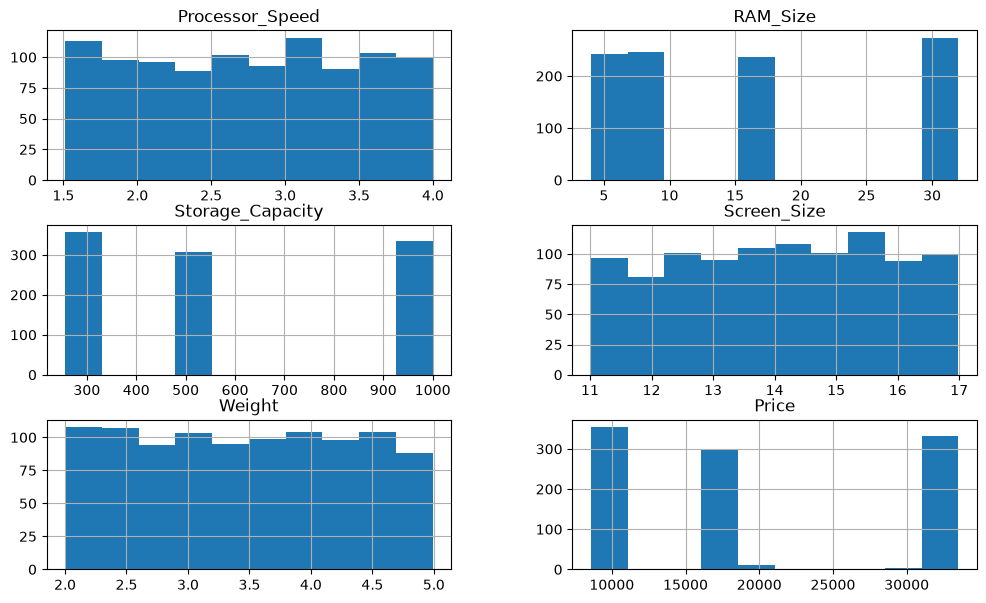

In [12]:
data.select_dtypes(include=["int64","float"]).hist(figsize=(12,7))
plt.show()

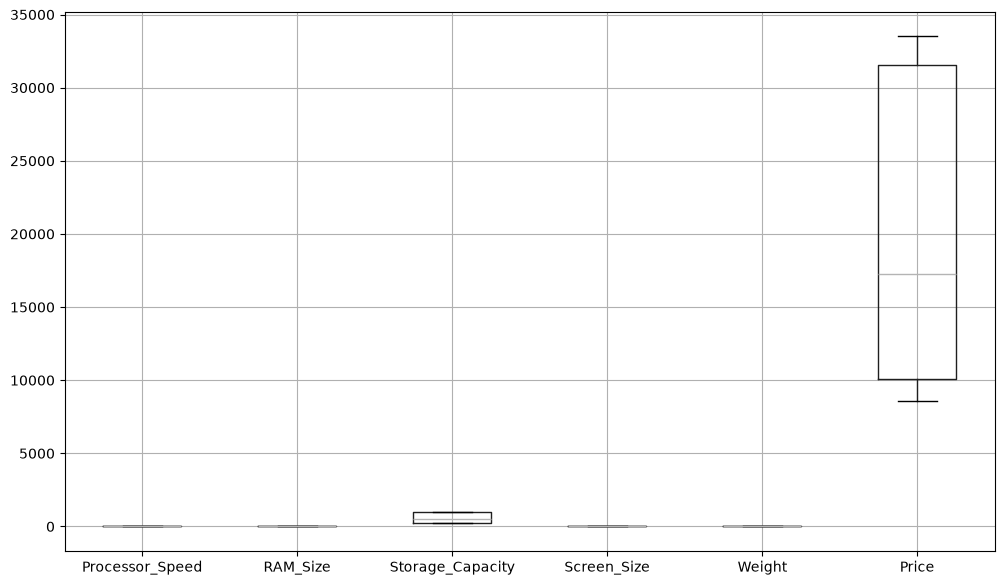

In [13]:
data.select_dtypes(include=["int","float"]).boxplot(figsize=(12,7))
plt.show()

######
DATA CLEANING


In [14]:
data.isnull().sum().sort_values(ascending=False)

Brand               0
Processor_Speed     0
RAM_Size            0
Storage_Capacity    0
Screen_Size         0
Weight              0
Price               0
dtype: int64

In [15]:
data.duplicated().sum()

np.int64(0)

#####
preprosecing

In [16]:
def remove_outlierr(data, column=[], factor=1.5):
    for i in column :
      q1 = data[i].quantile(0.25)
      q3 = data[i].quantile(0.75)
      iqr = q3 - q1
      lower = q1 - (factor * iqr)
      upper = q3 + (factor * iqr)
      data = data[
        (data[i] >= lower) &
        (data[i] <= upper) 
      ]
    return data
data=remove_outlierr(data, column=["Processor_Speed","Storage_Capacity","Screen_Size","Weight","Price","RAM_Size"])

In [17]:
data_x=data.drop("Price",axis=True)
data_y=data["Price"]

In [18]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train ,y_test =train_test_split(data_x,data_y,random_state=55,test_size=0.20)

In [19]:
def valuess(dataa):
    liststring=dataa.select_dtypes(include="str").columns
    for i in liststring:
        value=dataa[i].nunique()
        print(f"the values for column --{i}-- is-->",value)

In [20]:
valuess(data)

the values for column --Brand-- is--> 5


In [21]:
"""from sklearn.preprocessing import OrdinalEncoder
categorical_cols = x_train.select_dtypes(include=['object', 'category']).columns
label_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
x_train[categorical_cols] = label_enc.fit_transform(x_train[categorical_cols])
x_test[categorical_cols] = label_enc.transform(x_test[categorical_cols])"""

"from sklearn.preprocessing import OrdinalEncoder\ncategorical_cols = x_train.select_dtypes(include=['object', 'category']).columns\nlabel_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)\nx_train[categorical_cols] = label_enc.fit_transform(x_train[categorical_cols])\nx_test[categorical_cols] = label_enc.transform(x_test[categorical_cols])"

In [22]:
from sklearn.preprocessing import OneHotEncoder
one_hot=OneHotEncoder(handle_unknown="ignore")

a_data=one_hot.fit_transform(x_train[["Brand"]]).toarray()
b_data=one_hot.transform(x_test[["Brand"]]).toarray()
new_column=one_hot.get_feature_names_out(["Brand"])

a_data_frame=pd.DataFrame(data=a_data,index=x_train.index ,columns=new_column)
b_data_frame=pd.DataFrame(data=b_data,index=x_test.index ,columns=new_column)

x_train = pd.concat([a_data_frame,x_train],axis=1)
x_test= pd.concat([b_data_frame,x_test],axis=1)
x_train=x_train.drop(columns=["Brand"])
x_test=x_test.drop(columns=["Brand"])

In [23]:
x_train

,Brand_Acer,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight
349,1.0,0.0,0.0,0.0,0.0,3.696575,8,256,15.239806,4.747365
499,0.0,0.0,1.0,0.0,0.0,2.000376,16,1000,14.865540,3.956825
467,0.0,0.0,0.0,0.0,1.0,2.638050,16,256,11.032077,3.471226
293,0.0,1.0,0.0,0.0,0.0,2.079179,8,1000,15.179764,3.400184
580,0.0,1.0,0.0,0.0,0.0,2.613263,8,512,12.814874,2.531980
...,...,...,...,...,...,...,...,...,...,...
893,0.0,1.0,0.0,0.0,0.0,3.412025,16,256,14.073802,3.433226
968,0.0,1.0,0.0,0.0,0.0,1.875122,4,512,12.146793,2.649738
295,1.0,0.0,0.0,0.0,0.0,3.124117,4,512,16.598763,2.498158
666,1.0,0.0,0.0,0.0,0.0,1.766483,16,256,14.533598,4.559988


In [24]:
"""from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
scalrz_x_train =scalar.fit_transform(x_train)
scalrz_y_train =scalar.transform(x_test)"""

'from sklearn.preprocessing import StandardScaler\nscalar=StandardScaler()\nscalrz_x_train =scalar.fit_transform(x_train)\nscalrz_y_train =scalar.transform(x_test)'

In [25]:
from sklearn.tree import DecisionTreeRegressor ,plot_tree
from sklearn.metrics import mean_absolute_error, r2_score
model = DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42)
model.fit(x_train, y_train)

y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

 
print(f"--- R2 Score (Accuracy equivalent) ---")
print(f"Train R2: {train_r2 * 100:.2f}%")
print(f"Test R2: {test_r2 * 100:.2f}%\n")

print(f"--- Mean Absolute Error (MAE) ---")
print(f"Train MAE: {train_mae:.2f}")
print(f"Test MAE: {test_mae:.2f}")

--- R2 Score (Accuracy equivalent) ---
Train R2: 99.98%
Test R2: 99.93%

--- Mean Absolute Error (MAE) ---
Train MAE: 115.60
Test MAE: 204.08


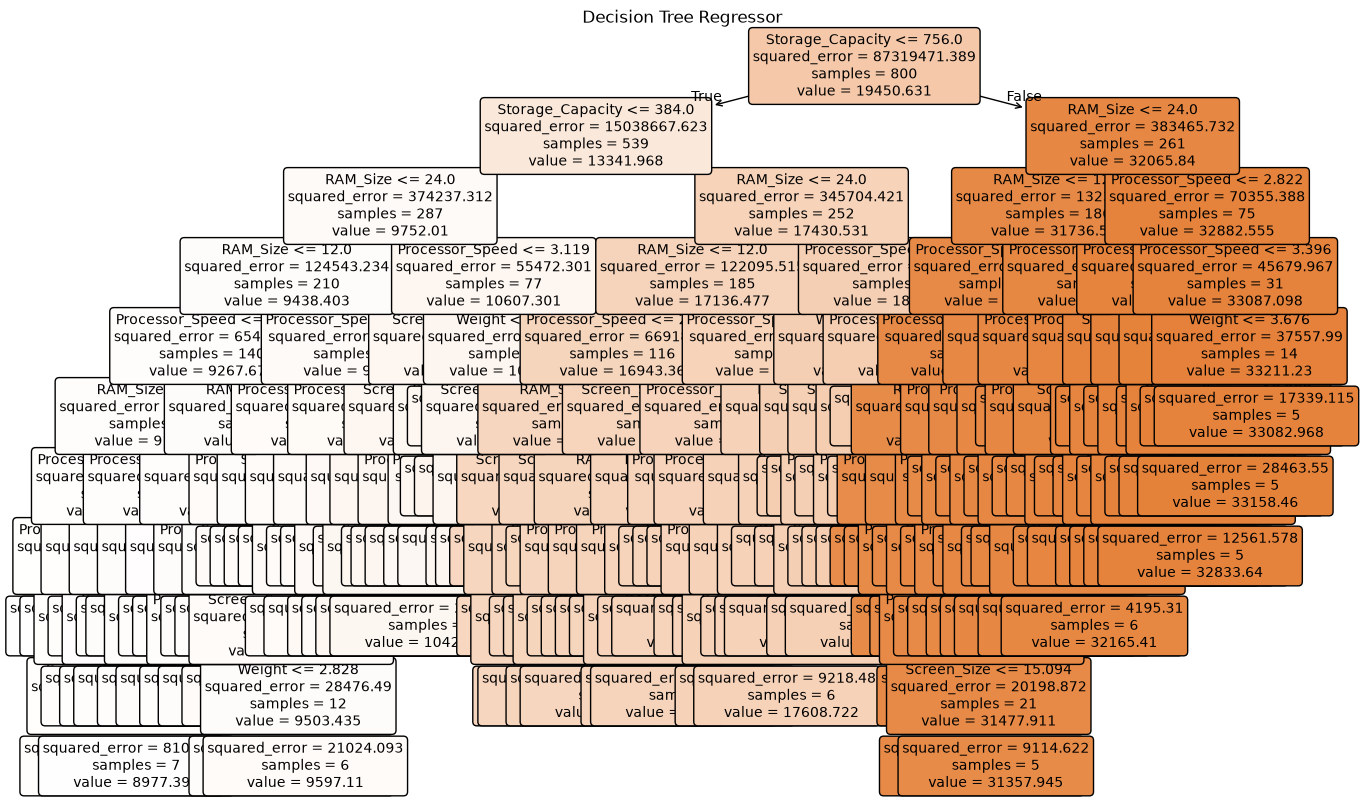

In [26]:
plt.figure(figsize=(15,10))
plot_tree(
    model,
    feature_names=x_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Regressor")
plt.show()